# Saudi Digital Concierge — Data Exploration
## Source 6: Booking.com Hotels

**File:** `data/raw/Booking.com/project3_df1.csv`
**Purpose:** accommodation — hotels & apartments with price, star rating, customer
rating, room/occupancy details, and coordinates.

This source fills the "where to stay" gap the other sources don't cover. This notebook
profiles it, parses the messy string fields (price, occupancy, tax), assesses coverage
and quality, and ends with cleaning steps.

> **Note:** the booking links embed `checkin=2020-04-24`, so this is a **2020 snapshot** —
> prices/availability are historical, not live.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CSV = BASE / "data" / "raw" / "Booking.com" / "project3_df1.csv"

df = pd.read_csv(CSV).rename(columns={"Unnamed: 0": "idx"})
print("Shape:", df.shape)
df.head(3)

Shape: (1025, 21)


,idx,Name,City,Price,Star_Rating,Property_Demand,Property_id,Customers_Rating,Customers_Review,Type_of_room,reservations_Payment,Canelation,Max_persons,Bed_type,Tax,Review_title,Credit_card,Breakfst_included,Longitude_x,Latitude_y,Link
0,0,الريـم,Al Ula,SAR 179,5,Only 1 room left like this on our site,6330099,NaN,NaN,Economy Double Room,No prepayment needed,FREE cancellation,Max persons: 2,3 beds\n(3 large doubles),+SAR 0 taxes and charges,NaN,Reservation possible without a credit card,NaN,37.917525,26.648656,https://www.booking.com/hotel/sa/lrym.en-gb.ht...
1,1,Copper Crown Furnished Apartments,Khamis Mushayt,SAR 195,5,Only 2 rooms like this left on our site,5326174,9.0,169 reviews,Deluxe Room (2 Adults + 1 Child),No prepayment needed,FREE cancellation,Max persons: 2,1 bed\n(1 extra-large double),includes taxes and charges,Superb,Reservation possible without a credit card,NaN,42.801402,18.242741,https://www.booking.com/hotel/sa/kwbr-krwn-lls...
2,2,فندق راية الشلال 2,Abū Qa‘ar,SAR 200,5,Only 3 rooms like this left on our site,5987844,8.7,17 reviews,Deluxe Double or Twin Room,No prepayment needed,FREE cancellation,Max persons: 2,1 bed\n(1 double),+SAR 0 taxes and charges,Fabulous,Reservation possible without a credit card,NaN,45.990981,28.370666,https://www.booking.com/hotel/sa/fndq-ry-lshll...


## 1. Schema & column dictionary

| Column | Meaning |
| ------ | ------- |
| `Name` | Property name (Arabic or English) |
| `City` | Location — sometimes a neighbourhood + city (`Ajyad, Makkah`) |
| `Price` | Nightly price, e.g. `SAR 179` |
| `Star_Rating` | Official stars 0–5 (**0 = unrated**, e.g. apartments) |
| `Property_Demand` | Scarcity text (`Only 1 room left …`) |
| `Property_id` | Unique property id |
| `Customers_Rating` | Guest score, 0–10 scale |
| `Customers_Review` | Review count text (`169 reviews`) |
| `Type_of_room`, `Bed_type`, `Max_persons` | Room details |
| `reservations_Payment`, `Canelation`, `Credit_card` | Booking terms |
| `Tax`, `Breakfst_included` | Extras |
| `Review_title` | Qualitative label (`Superb`, `Good`) |
| `Longitude_x`, `Latitude_y` | Coordinates |
| `Link` | Booking.com URL (2020 snapshot) |

In [2]:
df.info()
print("\nExact duplicate rows:", df.drop(columns='idx').duplicated().sum())
print("Unique Property_id:", df['Property_id'].nunique(), "/", len(df))

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idx                   1025 non-null   int64  
 1   Name                  1025 non-null   str    
 2   City                  1025 non-null   str    
 3   Price                 1025 non-null   str    
 4   Star_Rating           1025 non-null   int64  
 5   Property_Demand       750 non-null    str    
 6   Property_id           1025 non-null   int64  
 7   Customers_Rating      956 non-null    float64
 8   Customers_Review      956 non-null    str    
 9   Type_of_room          1024 non-null   str    
 10  reservations_Payment  735 non-null    str    
 11  Canelation            846 non-null    str    
 12  Max_persons           1025 non-null   str    
 13  Bed_type              1006 non-null   str    
 14  Tax                   1025 non-null   str    
 15  Review_title          956 non-nu

## 2. Missing values

In [3]:
miss = pd.DataFrame({
    "missing": df.drop(columns='idx').isna().sum(),
    "missing_%": (df.drop(columns='idx').isna().mean()*100).round(1),
}).sort_values("missing", ascending=False)
miss[miss["missing"] > 0]

,missing,missing_%
Breakfst_included,941,91.8
Credit_card,321,31.3
reservations_Payment,290,28.3
Property_Demand,275,26.8
Canelation,179,17.5
Review_title,69,6.7
Customers_Review,69,6.7
Customers_Rating,69,6.7
Bed_type,19,1.9
Type_of_room,1,0.1


## 3. Price (parsed)
`Price` is text like `SAR 179`. Strip the currency and cast to a number.

Parsed prices: 1025 / 1025
count    1025.0
mean      269.0
std       451.0
min        23.0
25%       100.0
50%       130.0
75%       280.0
max      7907.0


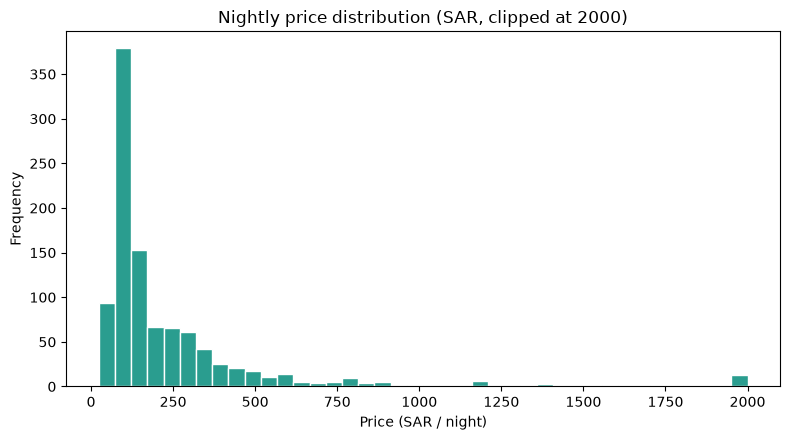

In [4]:
df["price_sar"] = pd.to_numeric(
    df["Price"].str.replace("SAR", "", regex=False).str.replace(",", "").str.strip(),
    errors="coerce")
print("Parsed prices:", df["price_sar"].notna().sum(), "/", len(df))
print(df["price_sar"].describe().round(0).to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
df["price_sar"].clip(upper=2000).plot(kind="hist", bins=40, ax=ax, color="#2a9d8f", edgecolor="white")
ax.set_title("Nightly price distribution (SAR, clipped at 2000)")
ax.set_xlabel("Price (SAR / night)")
plt.tight_layout()
plt.show()

## 4. Ratings — stars vs guest score
`Star_Rating` (0–5, 0 = unrated) is the official class; `Customers_Rating` (0–10) is the
guest score. They measure different things.

Star_Rating distribution (0 = unrated):
Star_Rating
0    532
1      4
2     51
3    191
4    164
5     83

Star_Rating == 0 (unrated): 532 (52%)

Customers_Rating (0-10):
count    956.00
mean       7.39
std        1.07
min        3.40
25%        6.70
50%        7.50
75%        8.20
max        9.60


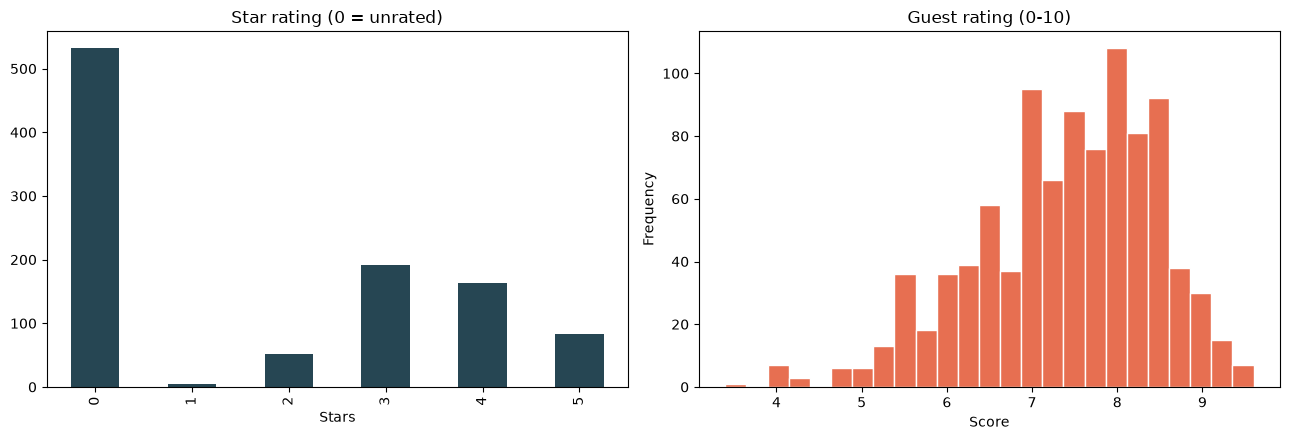

In [5]:
print("Star_Rating distribution (0 = unrated):")
print(df["Star_Rating"].value_counts().sort_index().to_string())
print(f"\nStar_Rating == 0 (unrated): {(df['Star_Rating']==0).sum()} "
      f"({(df['Star_Rating']==0).mean()*100:.0f}%)")
print("\nCustomers_Rating (0-10):")
print(df["Customers_Rating"].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df["Star_Rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#264653")
axes[0].set_title("Star rating (0 = unrated)"); axes[0].set_xlabel("Stars")
df["Customers_Rating"].plot(kind="hist", bins=25, ax=axes[1], color="#e76f51", edgecolor="white")
axes[1].set_title("Guest rating (0-10)"); axes[1].set_xlabel("Score")
plt.tight_layout()
plt.show()

## 5. City coverage
`City` mixes neighbourhoods with cities (`Al Olayya, Al Khobar`). A base-city extraction
(text after the last comma) gives cleaner coverage.

Raw City values:

 112 | base cities: 85

Top base cities:
base_city
Jeddah            208
Riyadh            169
Makkah             83
Al Khobar          83
Dammam             59
Abha               36
Al Madinah         36
Taif               32
Yanbu              32
Buraydah           31
Jazan              23
Tabuk              23
Khamis Mushayt     20
Hail               17
Al Jubail          16


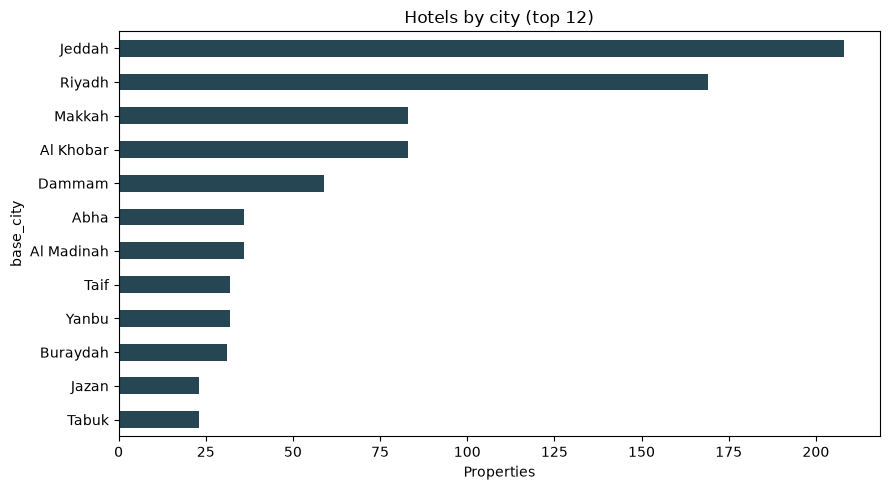

In [6]:
df["base_city"] = df["City"].str.split(",").str[-1].str.strip()
print("Raw City values:", df["City"].nunique(), "| base cities:", df["base_city"].nunique())
print("\nTop base cities:")
print(df["base_city"].value_counts().head(15).to_string())

top = df["base_city"].value_counts().head(12)
fig, ax = plt.subplots(figsize=(9, 5))
top.plot(kind="barh", ax=ax, color="#264653")
ax.invert_yaxis(); ax.set_title("Hotels by city (top 12)"); ax.set_xlabel("Properties")
plt.tight_layout()
plt.show()

## 6. Geographic coverage
Unlike the Riyadh-only places source, hotels have coordinates **nationwide**.

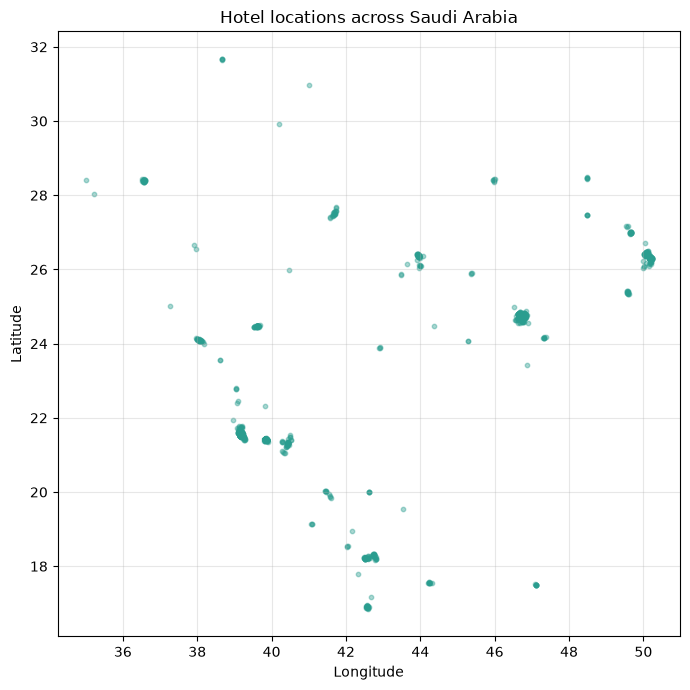

Lat range: 16.85 - 31.68
Lon range: 35.01 - 50.22


In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df["Longitude_x"], df["Latitude_y"], s=10, alpha=0.4, color="#2a9d8f")
ax.set_title("Hotel locations across Saudi Arabia")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Lat range:", round(df['Latitude_y'].min(),2), "-", round(df['Latitude_y'].max(),2))
print("Lon range:", round(df['Longitude_x'].min(),2), "-", round(df['Longitude_x'].max(),2))

## 7. Room, occupancy & booking terms
Parse `Max_persons` and summarise the categorical booking-term fields.

In [8]:
df["max_persons"] = df["Max_persons"].str.extract(r"(\d+)").astype(float)
print("Max persons range:", df["max_persons"].min(), "-", df["max_persons"].max())
print("\nBreakfast included:")
print(df["Breakfst_included"].value_counts(dropna=False).to_string())
print("\nCancellation:")
print(df["Canelation"].value_counts(dropna=False).to_string())
print("\nReview_title (qualitative labels):")
print(df["Review_title"].value_counts(dropna=False).to_string())

Max persons range: 1.0 - 21.0

Breakfast included:
Breakfst_included
NaN                   941
Breakfast included     84

Cancellation:
Canelation
FREE cancellation    846
NaN                  179

Review_title (qualitative labels):
Review_title
 Good             347
 Review score     286
 Very good        215
 Fabulous          72
NaN                69
 Superb            32
 Exceptional        4


## 8. Findings & cleaning recommendations

**Overview**
- **1,025 rows × 21 columns**. `Property_id` is a clean **unique key** (0 duplicates).
  `Unnamed: 0` is a redundant index.
- **2020 snapshot** (booking links carry `checkin=2020-04-24`) — treat price/availability
  as historical, not live.

**Coverage & signal**
- Prices **SAR 23–7,907**, median **~130** SAR/night.
- **Nationwide coordinates** (lat 16.8–31.7, lon 35–50) — 112 raw locations, ~top cities
  Riyadh, Jeddah, Dammam, Makkah, Al Khobar. This is the only source with geo outside Riyadh.
- Guest ratings 3.4–9.6 (mean ~7.4); qualitative labels (Good → Exceptional).

**Data-quality issues (for `src/cleaning`)**
1. **`Star_Rating == 0` for 532 rows (52%)** = unrated (apartments/unclassified), *not*
   zero-star. Treat 0 as "unrated", don't average it in.
2. **`Price` is text** (`SAR 179`) → parse to `price_sar` (done here).
3. **`City` mixes neighbourhood + city** (`Ajyad, Makkah`) → extract base city and map to
   the canonical city/province key used by the other sources.
4. **Sparse columns**: `Breakfst_included` 92% missing (treat missing as "not included/
   unknown"), `Credit_card`, `reservations_Payment`, `Property_Demand`, `Canelation`
   partly missing; `Customers_Rating`/`Review`/`Review_title` 69 missing.
5. **Typos in column names** (`Canelation`, `Breakfst_included`, `Longitude_x`,
   `Latitude_y`) → rename to clean, consistent names.
6. **`Max_persons`, `Tax`, `Customers_Review` are text** → parse to numeric where useful.
7. **`Link`** is a long URL — keep as a source reference, exclude from embeddings.

**Concierge relevance:** high — this is the **accommodation** source (hotels + apartments)
with price, rating, occupancy and **nationwide coordinates**, enabling "affordable
family hotel in Makkah near the Haram" style answers. Complements places/events/
entertainment. Just flag results as 2020-era pricing.

**Next:** clean per above → tidy `hotels` table in `data/processed/`; embed
name + city + star/guest rating + room type + price into the vector store.